# CNN (Convolutional Neural Network)

# CNN Multi Classification

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

## 데이터 불러오기

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
class_name = ['Tshirt_top','Trouser','Pullover','Dress','Coat',
              'Sandal','Shirt','Sneaker','Bag','AnkleBoot']

### EDA

In [ ]:
pd.Series(y_train).value_counts().sort_index()

,count
0,6000
1,6000
2,6000
3,6000
4,6000
5,6000
6,6000
7,6000
8,6000
9,6000


### 랜덤 확인

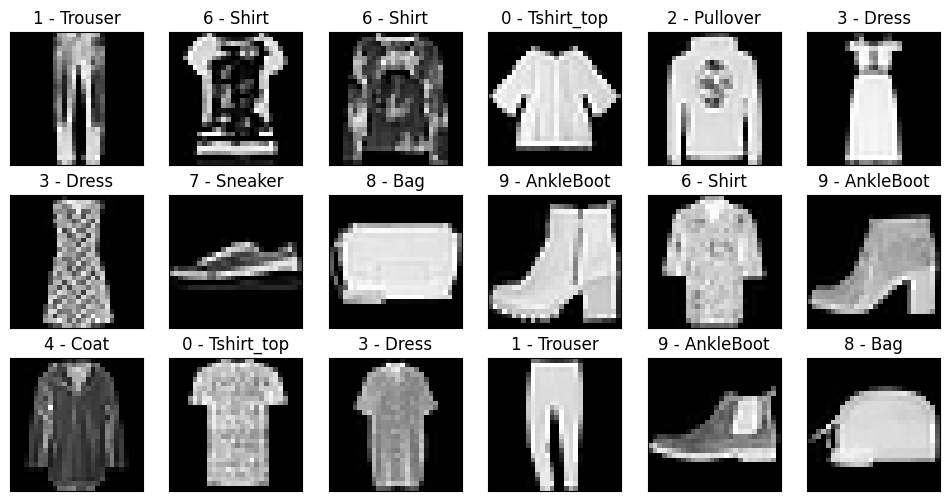

In [ ]:
samples = np.random.randint(len(x_train), size=18)

plt.figure(figsize = (12, 6))
for i, idx in enumerate(samples):
    plt.subplot(3, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx], cmap = 'gray')
    plt.title(f'{y_train[idx].item()} - {class_name[y_train[idx].item()]}')
plt.show()


## 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                  test_size = 0.2, random_state = SEED, shuffle=True)

x_train.shape, x_val.shape, y_train.shape, y_val.shape

((48000, 28, 28), (12000, 28, 28), (48000,), (12000,))

## 전처리

### Scaling (Min Max)

x만

In [ ]:
x_train_s = x_train / 255.
x_val_s = x_val / 255.

### Encoding

y만 one hot encoding

In [ ]:
from keras.utils import to_categorical

y_train_e = to_categorical(y_train, num_classes=10)
y_val_e = to_categorical(y_val, num_classes=10)

### 밑에서 모델에 집어넣기 위해 reshape 필요

In [ ]:
x_train_s = x_train_s.reshape(-1, 28, 28, 1)
x_val_s = x_val_s.reshape(-1, 28, 28, 1)

In [ ]:
x_train_s.shape, x_val_s.shape, y_train_e.shape, y_val_e.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000, 10), (12000, 10))

## 모델 정의

In [ ]:
from keras import layers

def build_basic_model():
  model = keras.Sequential([

   keras.Input(shape=(28, 28, 1)),
   layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),

   layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),

   layers.Flatten(),
   layers.Dense(16, activation='relu'),

   layers.Dense(10, activation='softmax')   # output layer
  ])
  return model

early stopping 기능도 탑재해보자.

In [ ]:
def build_dropout_model():
    model = keras.Sequential([

   keras.Input(shape=(28, 28, 1)),
   layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),
   layers.Dropout(0.25),

   layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),

   layers.Dropout(0.25),
   layers.Flatten(),
   layers.Dense(16, activation='relu'),

   layers.Dense(10, activation='softmax')   # output layer
  ])

    return model


In [ ]:
model = build_dropout_model()
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,786 (69.48 KB)

 Trainable params: 17,786 (69.48 KB)

 Non-trainable params: 0 (0.00 B)

## 컴파일

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 학습

In [ ]:
EPOCHS = 30

history = model.fit(
    x_train_s, y_train_e,
    epochs = EPOCHS,
    batch_size = 256,
    validation_data = (x_val_s, y_val_e)
)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6265 - loss: 1.0640 - val_accuracy: 0.7795 - val_loss: 0.6244
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7707 - loss: 0.6155 - val_accuracy: 0.8088 - val_loss: 0.5421
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7959 - loss: 0.5508 - val_accuracy: 0.8326 - val_loss: 0.4951
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8124 - loss: 0.5102 - val_accuracy: 0.8441 - val_loss: 0.4576
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8226 - loss: 0.4834 - val_accuracy: 0.8481 - val_loss: 0.4395
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8314 - loss: 0.4648 - val_accuracy: 0.8563 - val_loss: 0.4215
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8384 - loss: 0.4481 - val_accuracy: 0.8612 - val_loss: 0.4099
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8429 - loss: 0.4323 - val_accuracy: 0

### 학습 결과 그래프

In [ ]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))

  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

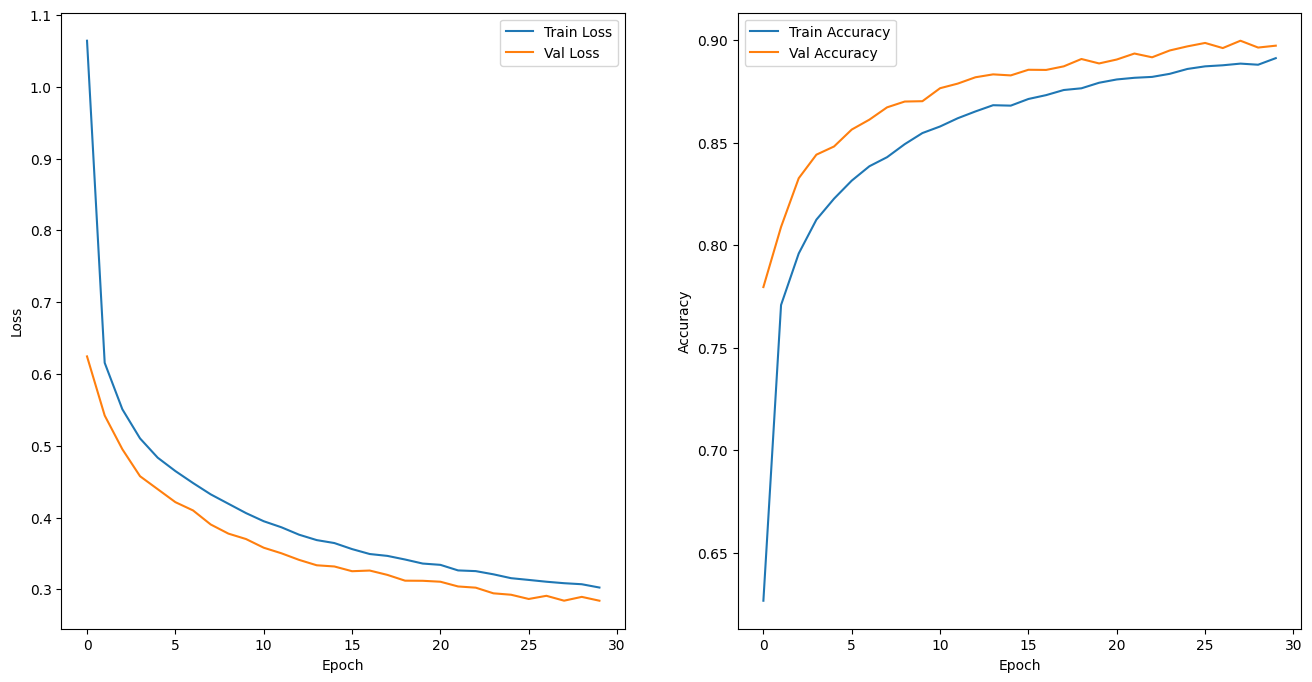

In [ ]:
plot_history(history)

## **테스트**

x scaling만 하고, y encoding은 생략

In [ ]:
x_test_s = x_test / 255.
x_test_s = x_test / 255.

In [ ]:
x_test_s = x_test_s.reshape(-1, 28*28)
x_test_s = x_test_s.reshape(-1, 28*28)

### 돌려보기

In [ ]:
y_pred = model.predict(x_test_s)
y_pred[:10]

### 결과확인

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred, average='macro')     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred, average='macro')    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred, average='macro')       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()